In [1]:
# Importing the modules
import pandas as pd
import numpy as np

In [2]:
# Reading the Data
df = pd.read_csv('Data/final_data.csv')
df

,Device,Price,Rating,price
0,"Lava Bold N2 (Siachen White, 4 GB RAM, 64 GB S...",9299.0,3.7,NaN
1,"Lava Bold N4 Lite (Empire Gold, 3GB RAM, 32GB ...",9299.0,3.3,NaN
2,"Samsung Galaxy M07 Mobile (Black, 4GB RAM, 64G...",15999.0,4.1,NaN
3,"REDMI A7 Pro 5G (Black, 4GB RAM,128GB Storage)...",12498.0,3.5,NaN
4,"Lava Agni 4 5G (8GB RAM, 256GB Storage, Phanto...",14499.0,4.3,NaN
...,...,...,...,...
375,"Smart Watch for Men, Bluetooth (Answer/Make Ca...",10978.0,4.3,NaN
376,Samsung Official S22 Smart Clear View Cover Wh...,13156.0,4.6,NaN
377,Smartphone Accessory Front Housing LCD Frame B...,9579.0,NaN,NaN
378,Smartphone Accessory Front Housing LCD Frame B...,9579.0,NaN,NaN


In [200]:
# Checking for data-types
df.dtypes

Device        str
Price     float64
Rating    float64
price     float64
dtype: object

In [201]:
# Checking the dataset
df.head()

,Device,Price,Rating,price
0,"Lava Bold N2 (Siachen White, 4 GB RAM, 64 GB S...",9299.0,3.7,NaN
1,"Lava Bold N4 Lite (Empire Gold, 3GB RAM, 32GB ...",9299.0,3.3,NaN
2,"Samsung Galaxy M07 Mobile (Black, 4GB RAM, 64G...",15999.0,4.1,NaN
3,"REDMI A7 Pro 5G (Black, 4GB RAM,128GB Storage)...",12498.0,3.5,NaN
4,"Lava Agni 4 5G (8GB RAM, 256GB Storage, Phanto...",14499.0,4.3,NaN


In [202]:
# Dropping unnecessary columns and Checking the number of rows and columns
df.drop(columns = 'price', inplace= True)

df.shape

(380, 3)

In [203]:
# Checking for Duplicates
df.duplicated().sum()

np.int64(108)

In [206]:
# removing Duplicates from Device name column
df.drop_duplicates('Device', inplace=True)

In [207]:
# Checking the number of rows and colunmns
df.shape

(268, 3)

In [208]:
df.tail()

,Device,Price,Rating
375,"Smart Watch for Men, Bluetooth (Answer/Make Ca...",10978.0,4.3
376,Samsung Official S22 Smart Clear View Cover Wh...,13156.0,4.6
377,Smartphone Accessory Front Housing LCD Frame B...,9579.0,NaN
378,Smartphone Accessory Front Housing LCD Frame B...,9579.0,NaN
379,Yedidya for Samsung Galaxy S25 Case 5G Smart V...,2389.0,NaN


Insight: The scraped dataset initially contained non-smartphone products such as cases, memory cards, pens, and power banks. These irrelevant products are to be identified and removed to make the analysis focused on smartphones.

In [210]:
# Removing the rows which are not Mobiles devices
df = df[df['Device'].str.contains('GB', case=False, na=False)]
df.shape

(197, 3)

In [211]:
df.sort_values('Device').head(50)

,Device,Price,Rating
135,(Pro)- 2.95 Inch 4G Smartphone | 3GB RAM + 32G...,4290.0,1.4
136,"AI+ Nova 2 Neo 5G Smartphone, 128 GB, Black, A...",12799.0,2.7
103,"Alcatel V3 Ultra 5G (Ocean Grey, 6GB+128GB) | ...",20725.0,3.0
240,"BlackBerry KEYone 32GB BBB100-1 - 4.5"" Inch Fa...",29699.0,3.1
311,Bold 17 Pro Smartphone 6GB/64GB Smartphone (Blue),10999.0,NaN
301,Bold S180 AIR Smartphone 6GB/64GB Smartphone,11499.0,NaN
309,Bold S180 AIR Smartphone 6GB/64GB Smartphone (...,11499.0,NaN
249,HIKVISION Extreme 32GB microSDXC Memory Card C...,1049.0,4.1
263,HIKVISION Extreme 64GB microSDXC Memory Card C...,1396.0,4.1
315,HP 64GB MicroSD Memory Card | SDXC mx310 Class...,1396.0,3.9


In [212]:
# Sorting the Dataset to only take Devices with Price > 4000 ti remove non-smartphone values 
df = df[df['Price'] >= 4000]

In [213]:
df.shape

(192, 3)

In [215]:
# Checking for any unnecessary values
df.sort_values('Price', ascending=True).head(50)

,Device,Price,Rating
52,"Pro 10-4G Smartphone 4.5"" Display | 3GB RAM 32...",4290.00,2.2
84,"Pro 16 4G Android Smartphone, 3GB RAM, 32 gb R...",4290.00,5.0
135,(Pro)- 2.95 Inch 4G Smartphone | 3GB RAM + 32G...,4290.00,1.4
99,PEACE MINI 6 Mini 3.75'' Inch 4G Smartphone (3...,4790.00,2.3
308,Samsung EVO Plus 128GB Micro SDXC w/SD Adaptor...,4999.99,1.0
12,PEACE Mi5 Pro Android Smartphone | 4GB RAM + 3...,5999.00,2.9
183,"PEACE Honor 20 Mini Smartphone, Octa-Core Perf...",5999.00,1.0
27,Pro -Halo 20-4.5 INCH Display 4G Smartphone wi...,6290.00,1.9
173,PEACE NOVA 11 4G Smartphone with 6.56-inch Dis...,6400.00,1.8
188,PEACE NOVA 11 4G Smartphone with 6.56-inch Dis...,6400.00,1.8


Removing `Memory Card` from the dataset

In [216]:
non_phone_keywords = ['Memory Card']

pattern = '|'.join(non_phone_keywords)

df = df[~df['Device'].str.contains(pattern, case=False, na=False)]

In [217]:
df.shape

(190, 3)

In [218]:
df.head(50)

,Device,Price,Rating
0,"Lava Bold N2 (Siachen White, 4 GB RAM, 64 GB S...",9299.0,3.7
1,"Lava Bold N4 Lite (Empire Gold, 3GB RAM, 32GB ...",9299.0,3.3
2,"Samsung Galaxy M07 Mobile (Black, 4GB RAM, 64G...",15999.0,4.1
3,"REDMI A7 Pro 5G (Black, 4GB RAM,128GB Storage)...",12498.0,3.5
4,"Lava Agni 4 5G (8GB RAM, 256GB Storage, Phanto...",14499.0,4.3
5,"Redmi Note 17 5G (Dark Night, 6GB RAM, 128GB R...",27999.0,3.2
6,Redmi 15C 5G Prime Edition Dusk Purple 6GB + 1...,21499.0,4.1
7,realme C71 4G Smartphone 4+64GB Blue,13199.0,4.3
8,"Lava Bold N2 5G (Billionaire Blue, 4GB RAM, 12...",8399.0,3.8
9,"Lava Bold N2 Lite (Kolar Gold, 3 GB RAM, 64 GB...",9999.0,3.7


In [219]:
df.sort_values('Price', ascending=True).head(25)

,Device,Price,Rating
52,"Pro 10-4G Smartphone 4.5"" Display | 3GB RAM 32...",4290.0,2.2
84,"Pro 16 4G Android Smartphone, 3GB RAM, 32 gb R...",4290.0,5.0
135,(Pro)- 2.95 Inch 4G Smartphone | 3GB RAM + 32G...,4290.0,1.4
99,PEACE MINI 6 Mini 3.75'' Inch 4G Smartphone (3...,4790.0,2.3
12,PEACE Mi5 Pro Android Smartphone | 4GB RAM + 3...,5999.0,2.9
183,"PEACE Honor 20 Mini Smartphone, Octa-Core Perf...",5999.0,1.0
27,Pro -Halo 20-4.5 INCH Display 4G Smartphone wi...,6290.0,1.9
10,SIAVANTAGEM Pro 25 Smartphone | 5.3 Inch HD Di...,6400.0,2.2
210,PEACE SC26 4G Smartphone with 6.56-inch Displa...,6400.0,NaN
188,PEACE NOVA 11 4G Smartphone with 6.56-inch Dis...,6400.0,1.8


In [220]:
# Creating a new brand column for the respective devices
brands = [
    'Samsung', 'Apple', 'OnePlus', 'realme', 'Redmi',
    'POCO', 'OPPO', 'Vivo', 'Motorola', 'Infinix',
    'Lava', 'Nokia', 'Google', 'Nothing', 'iQOO',
    'Tecno', 'Honor', 'ASUS', 'Xiaomi', 'PEACE', 'Mi', 'Philips', 'BlackBerry'
]

pattern = r'(?i)^(' + '|'.join(brands) + r')\b'

df['Brand'] = df['Device'].str.extract(pattern, expand=False)

In [222]:
# Checking the Count of each Brand
df['Brand'].value_counts()

Brand
realme        47
Samsung       15
REDMI         15
Motorola      14
Lava          12
Redmi         12
PEACE         12
Infinix        6
iQOO           6
Philips        6
POCO           5
vivo           5
Peace          5
OnePlus        4
OPPO           4
Oppo           1
Nothing        1
Poco           1
VIVO           1
BlackBerry     1
Xiaomi         1
Mi             1
Name: count, dtype: int64

In [223]:
# Checking null Brand Mobile Devices
df[df['Brand'].isna()]

,Device,Price,Rating,Brand
10,SIAVANTAGEM Pro 25 Smartphone | 5.3 Inch HD Di...,6400.0,2.2,NaN
27,Pro -Halo 20-4.5 INCH Display 4G Smartphone wi...,6290.0,1.9,NaN
52,"Pro 10-4G Smartphone 4.5"" Display | 3GB RAM 32...",4290.0,2.2,NaN
54,Zeno 100 Lite | UNISOC Octa-Core Processor | 2...,8599.0,3.2,NaN
59,Zeno 100 Lite | UNISOC Octa-Core Processor | 2...,8599.0,3.2,NaN
84,"Pro 16 4G Android Smartphone, 3GB RAM, 32 gb R...",4290.0,5.0,NaN
103,"Alcatel V3 Ultra 5G (Ocean Grey, 6GB+128GB) | ...",20725.0,3.0,NaN
113,"acerpure Acerone Liquid 4G Smartphone (Blue, 4...",8399.0,3.2,NaN
135,(Pro)- 2.95 Inch 4G Smartphone | 3GB RAM + 32G...,4290.0,1.4,NaN
136,"AI+ Nova 2 Neo 5G Smartphone, 128 GB, Black, A...",12799.0,2.7,NaN


## Visualization

In [224]:
import matplotlib.pyplot as plt
import seaborn as sns

#### Distribution of Mobile phones based on Price

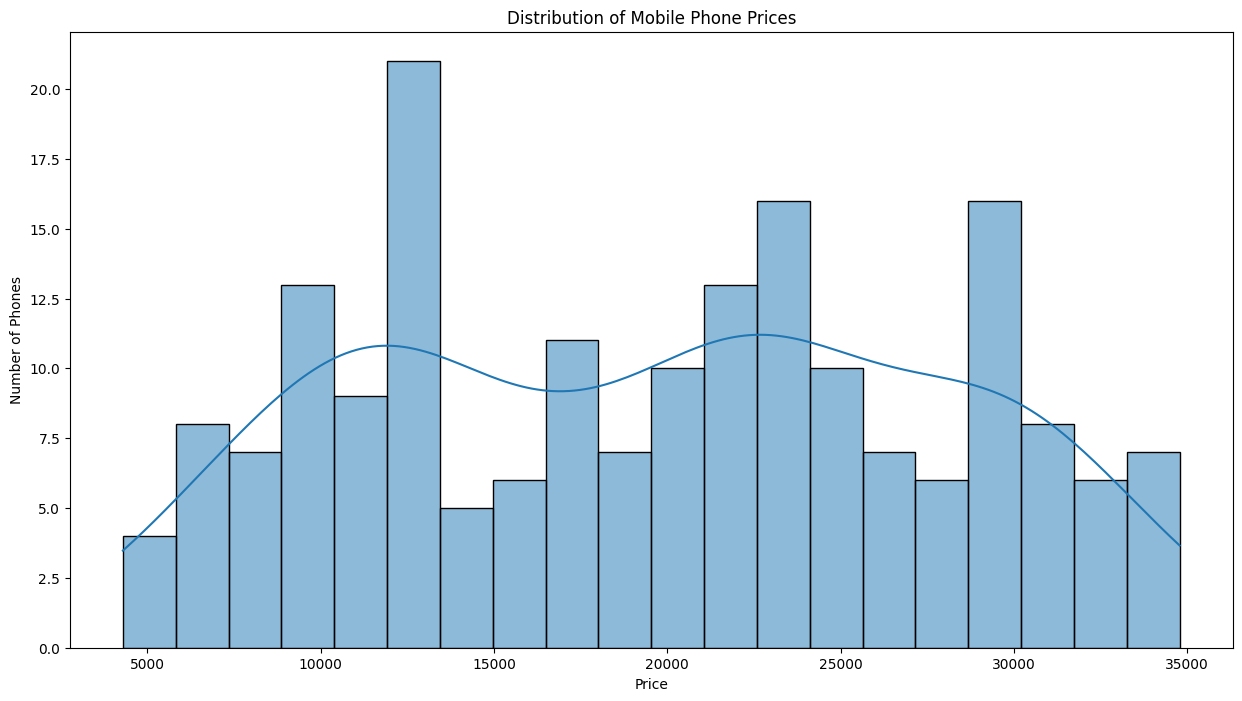

In [225]:
plt.figure(figsize=(15,8))
sns.histplot(df['Price'], bins=20, kde=True)
plt.title("Distribution of Mobile Phone Prices")
plt.xlabel("Price")
plt.ylabel("Number of Phones")
plt.show()

#### Distribution of Devices based on Rating    

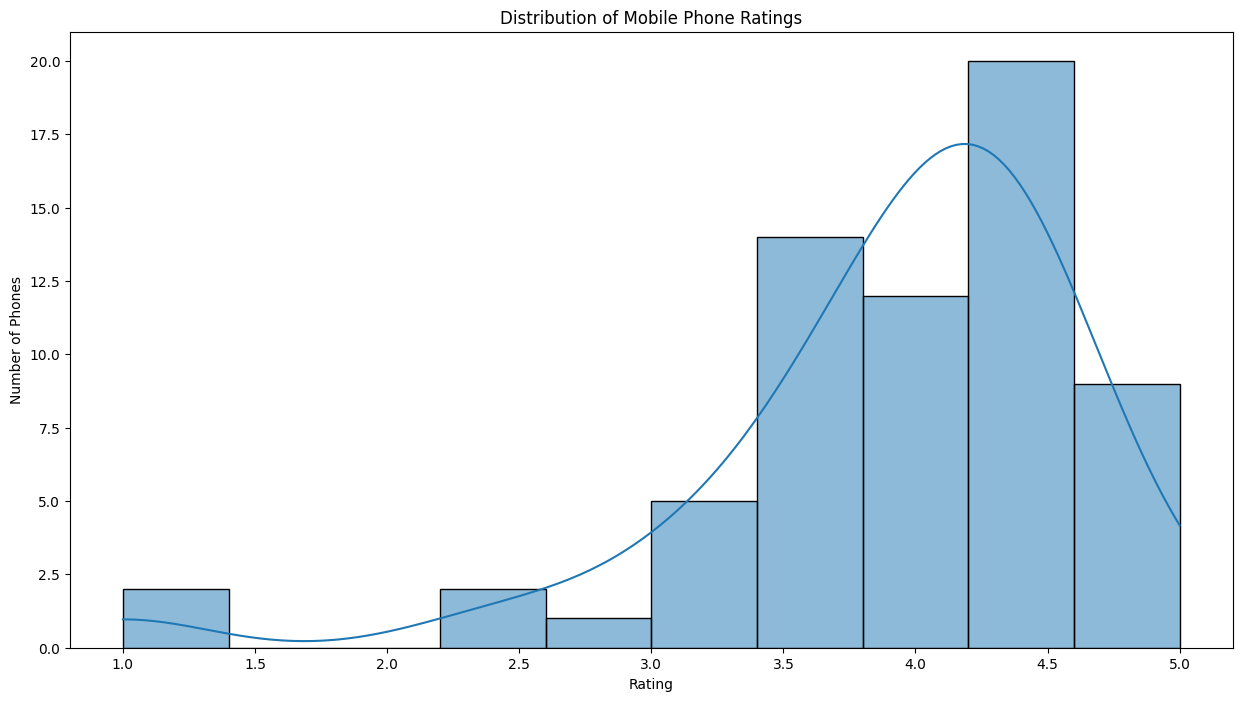

In [58]:
plt.figure(figsize=(15,8))
sns.histplot(df['Rating'], bins=10, kde=True)
plt.title("Distribution of Mobile Phone Ratings")
plt.xlabel("Rating")
plt.ylabel("Number of Phones")
plt.show()

---

### Brand Analysis

#### Number of Phones by Brand

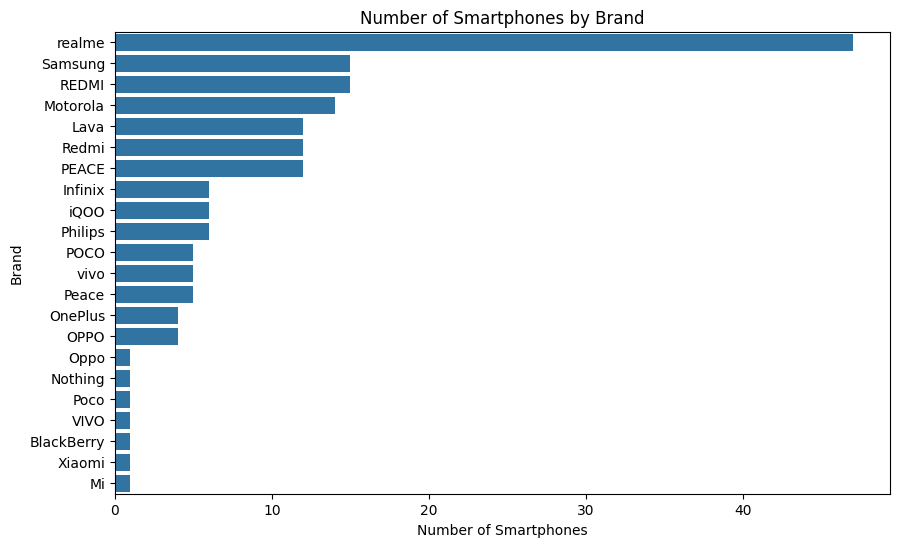

In [172]:
brand_counts = df['Brand'].value_counts()
plt.figure(figsize=(10, 6))

sns.barplot(
    x=brand_counts.values,
    y=brand_counts.index
)

plt.title('Number of Smartphones by Brand')
plt.xlabel('Number of Smartphones')
plt.ylabel('Brand')

plt.show()


#### Average Price of Device by Brand

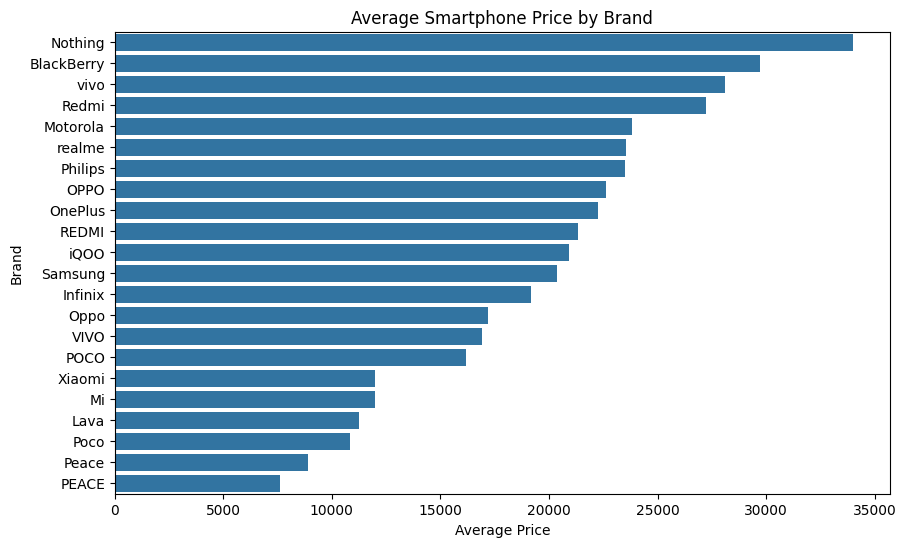

In [173]:
avg_price = (
    df.groupby('Brand')['Price']
      .mean()
      .sort_values(ascending=False)
)

avg_price

plt.figure(figsize=(10, 6))

sns.barplot(
    x=avg_price.values,
    y=avg_price.index
)

plt.title('Average Smartphone Price by Brand')
plt.xlabel('Average Price')
plt.ylabel('Brand')

plt.show()

#### Average Rating of Device by Brand

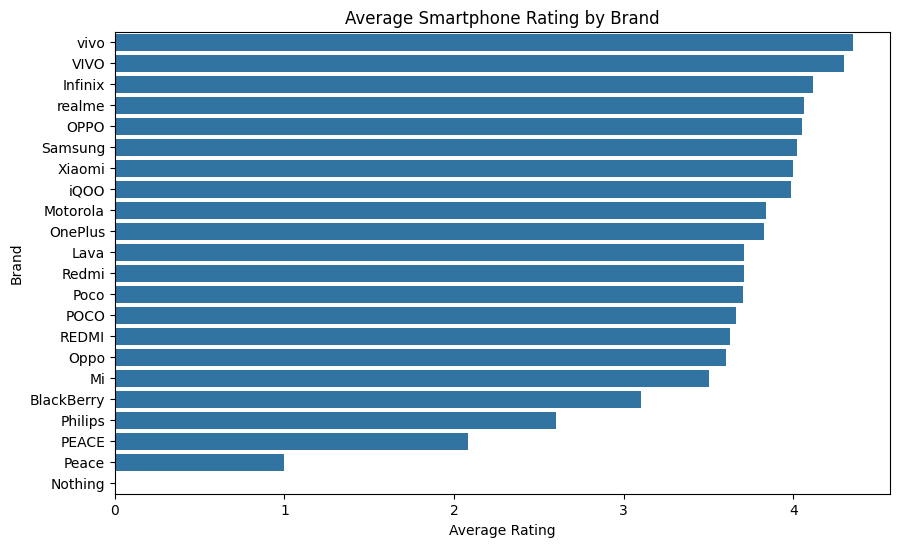

In [174]:
avg_rating = (
    df.groupby('Brand')['Rating']
      .mean()
      .sort_values(ascending=False)
)

plt.figure(figsize=(10, 6))

sns.barplot(
    x=avg_rating.values,
    y=avg_rating.index
)

plt.title('Average Smartphone Rating by Brand')
plt.xlabel('Average Rating')
plt.ylabel('Brand')

plt.show()

#### Smartphone Price Distribution by Brand

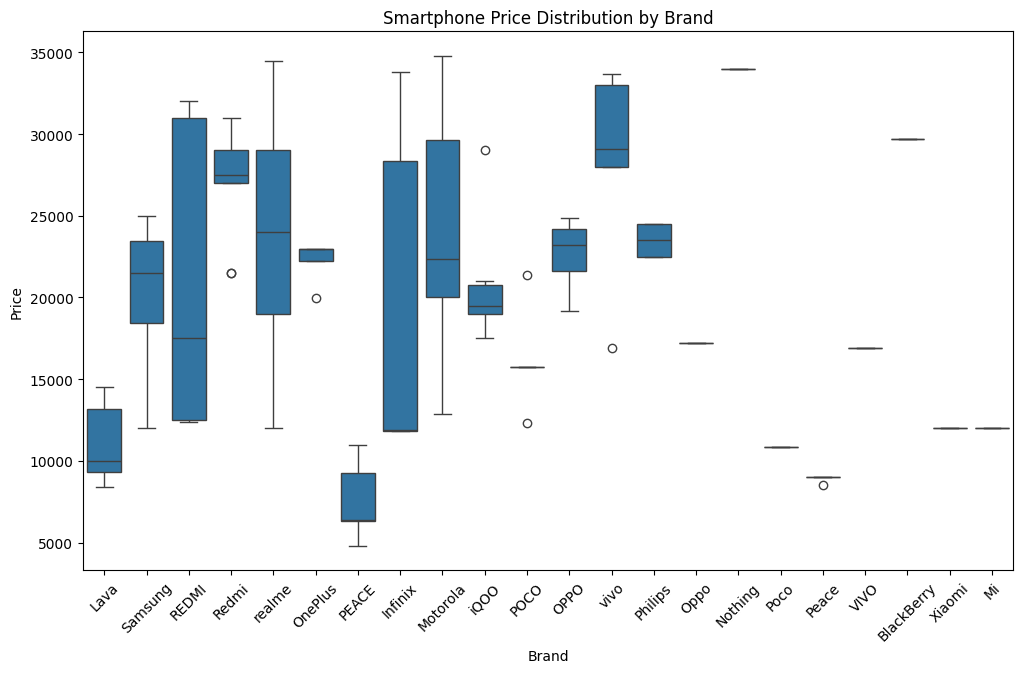

In [175]:
plt.figure(figsize=(12, 7))

sns.boxplot(
    data=df,
    x='Brand',
    y='Price'
)

plt.title('Smartphone Price Distribution by Brand')
plt.xlabel('Brand')
plt.ylabel('Price')

plt.xticks(rotation=45)
plt.show()


#### Relationship Analysis

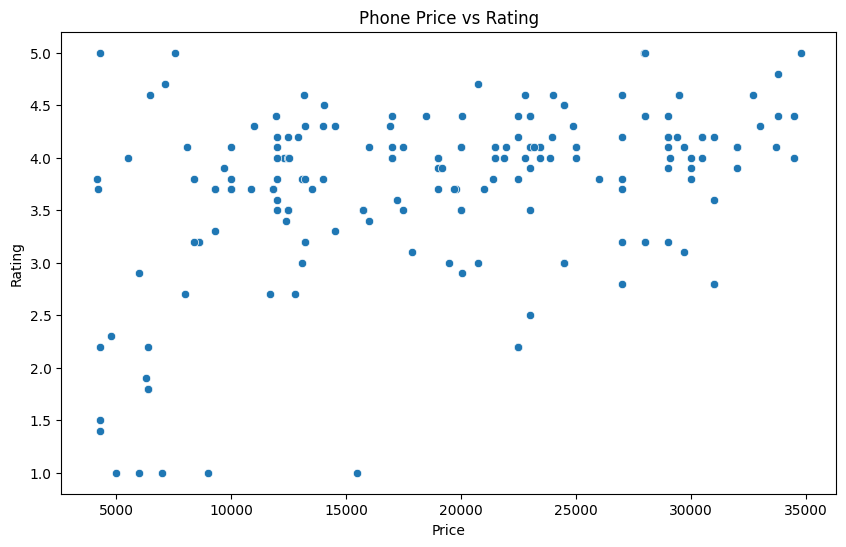

In [45]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="Price",
    y="Rating"
)

plt.title("Phone Price vs Rating")
plt.xlabel("Price")
plt.ylabel("Rating")
plt.show()

#### Brand vs Price

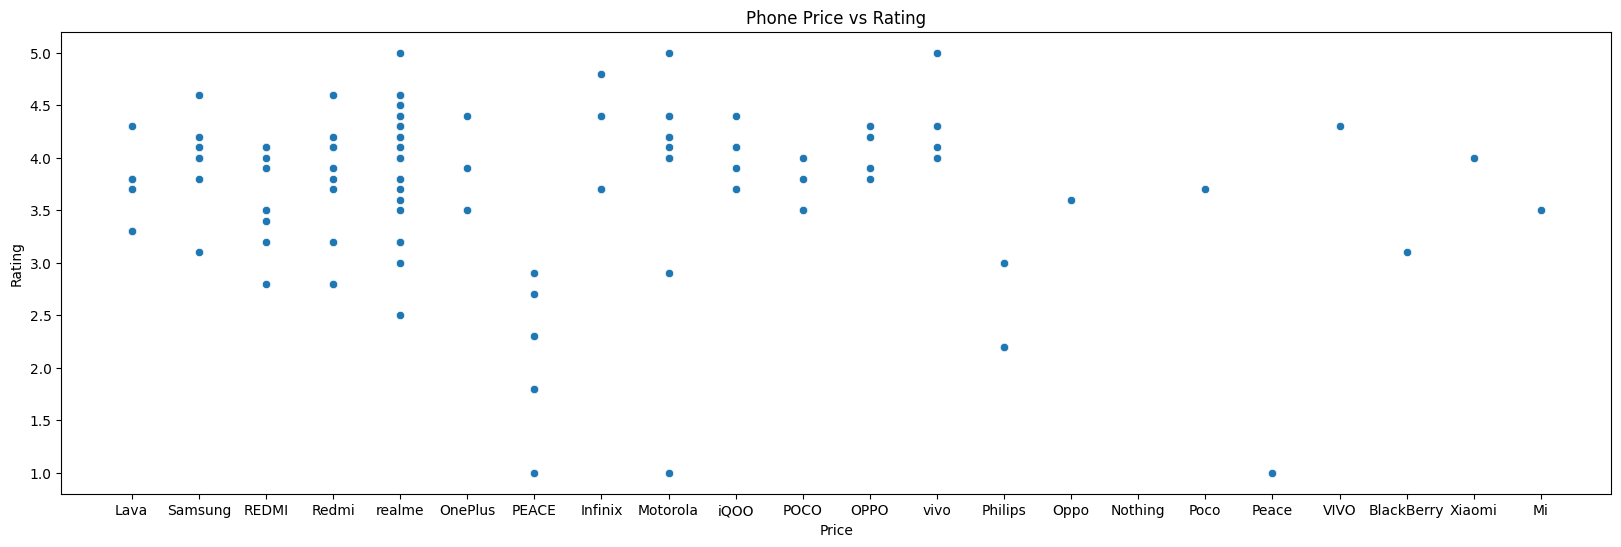

In [ ]:
plt.figure(figsize=(20, 6))

sns.scatterplot(
    data=df,
    x="Brand",
    y="Rating"
)

plt.title("Phone Price vs Rating")
plt.xlabel("Price")
plt.ylabel("Rating")
plt.show()

#### Co-Relation between Price and Rating

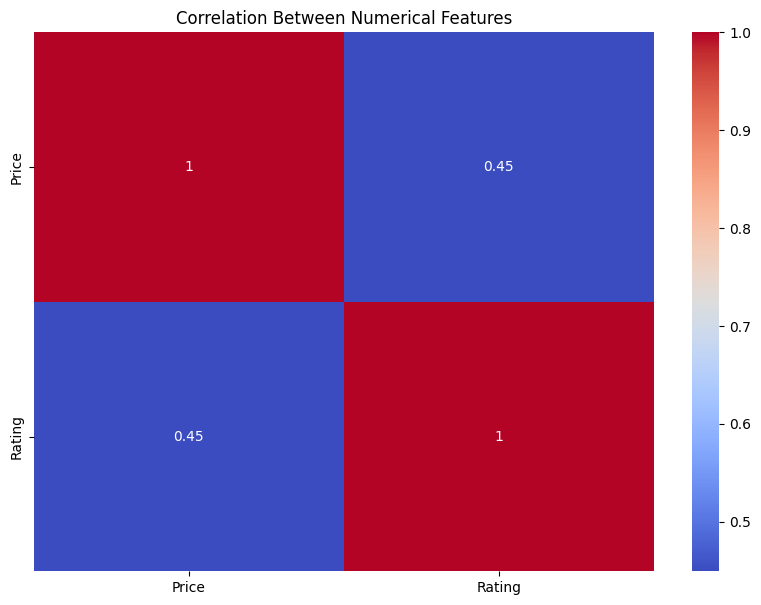

In [177]:
plt.figure(figsize=(10, 7))

sns.heatmap(
    df.select_dtypes("number").corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Between Numerical Features")
plt.show()

### Statistics

### Cheapest Devices

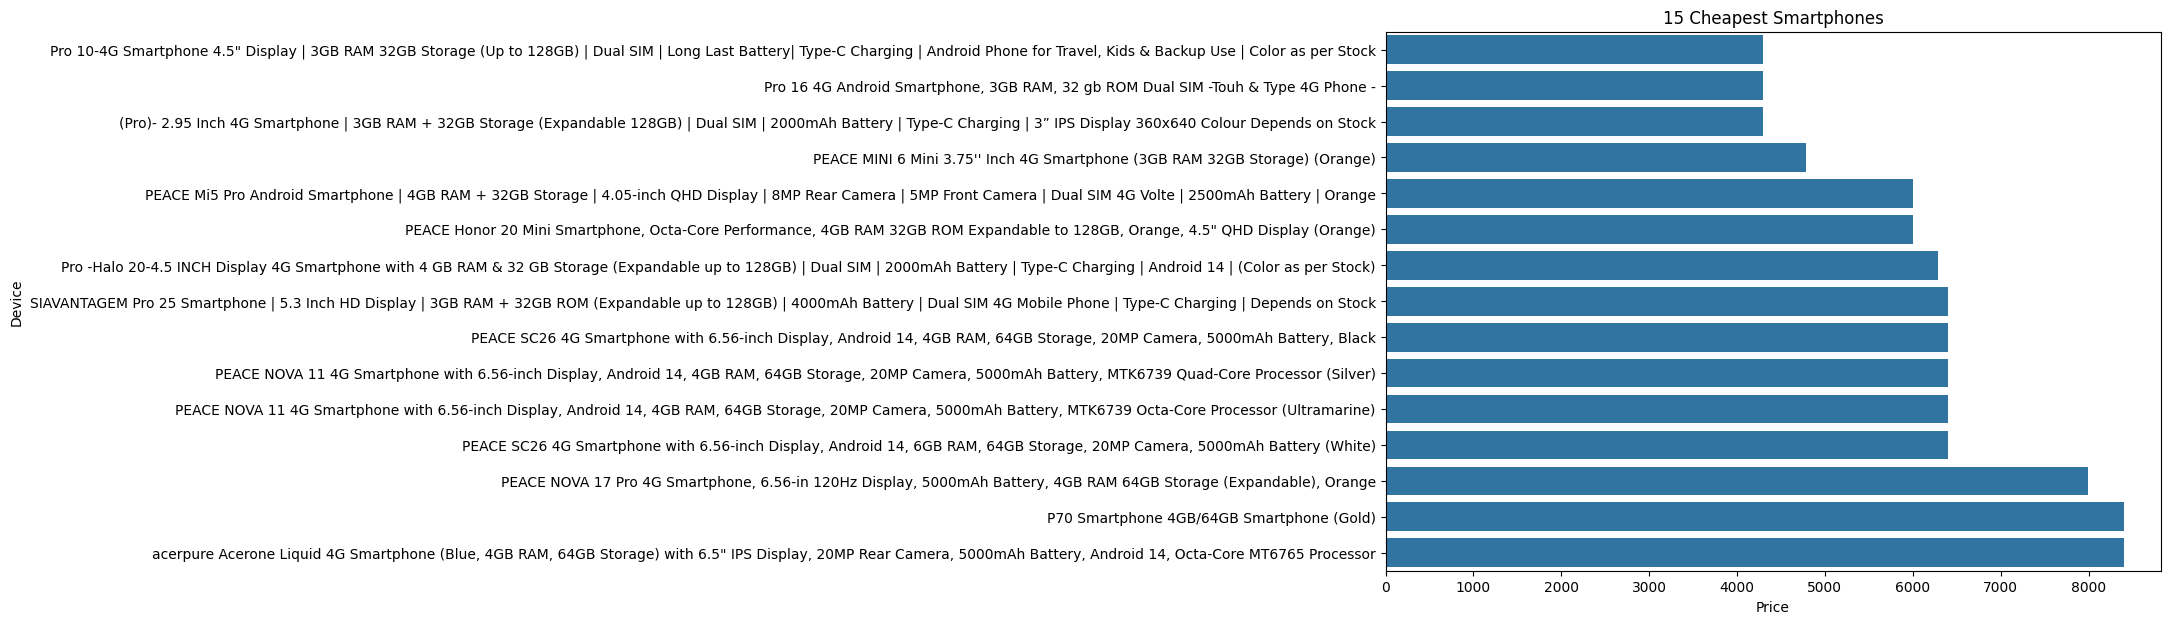

In [180]:
cheapest = df.sort_values('Price').head(15)

plt.figure(figsize=(10, 7))

sns.barplot(
    data=cheapest,
    x='Price',
    y='Device'
)

plt.title('15 Cheapest Smartphones')
plt.xlabel('Price')
plt.ylabel('Device')

plt.show()

#### Most Expensive Devices

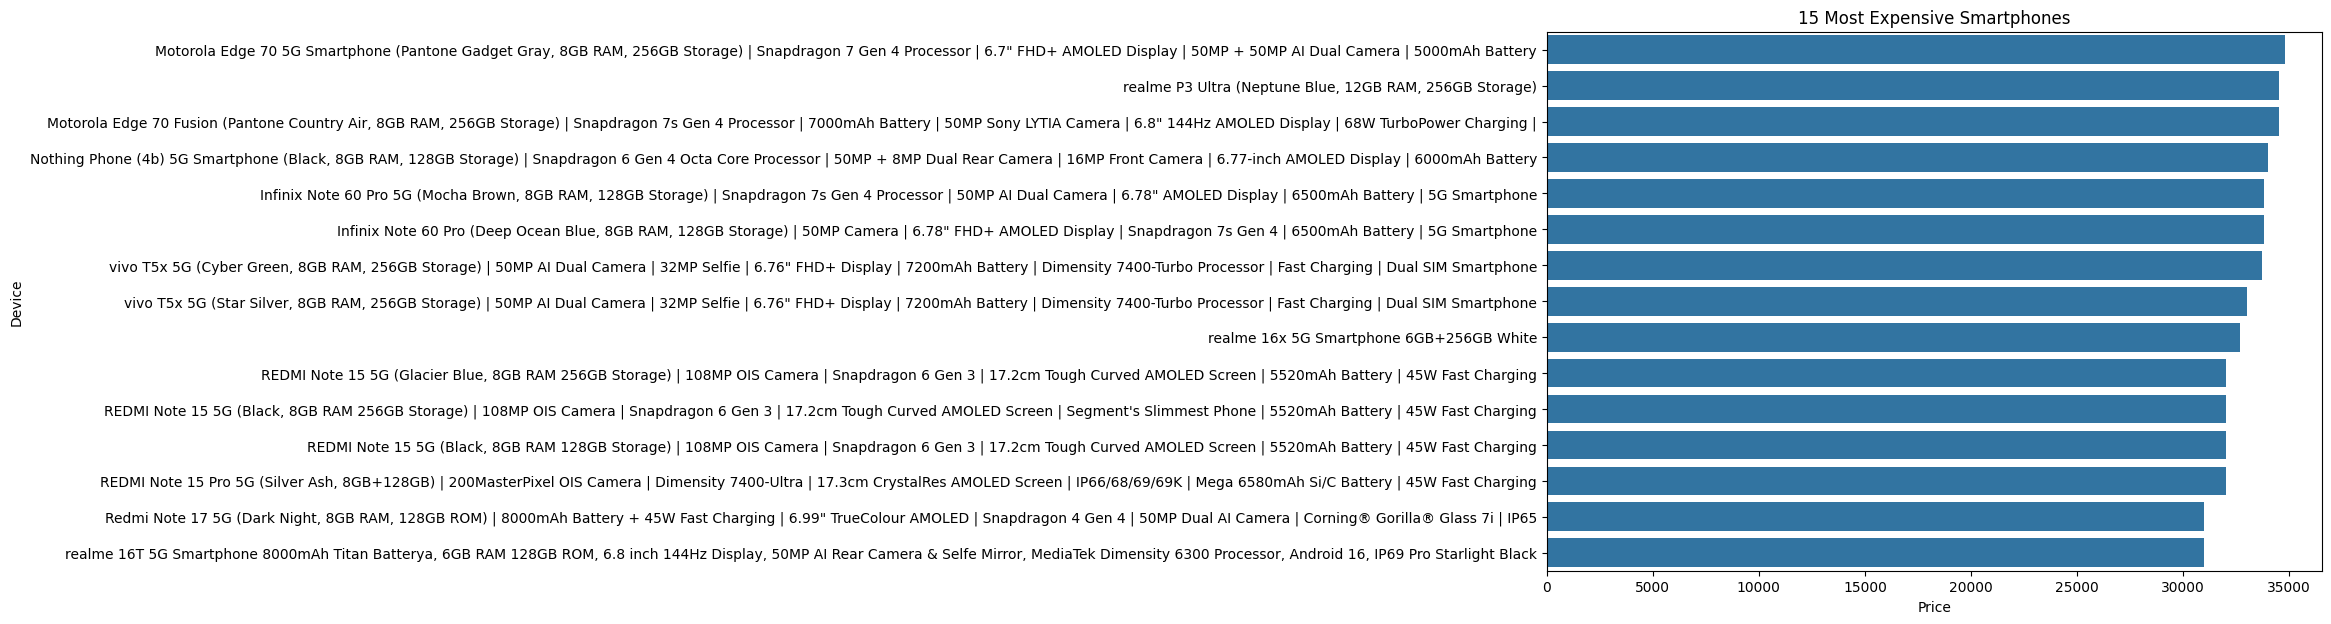

In [187]:
expensive = df.sort_values('Price', ascending=False).head(15)

plt.figure(figsize=(10, 7))

sns.barplot(
    data=expensive,
    x='Price',
    y='Device'
)

plt.title('15 Most Expensive Smartphones')
plt.xlabel('Price')
plt.ylabel('Device')

plt.show()


#### Top Rated Devices

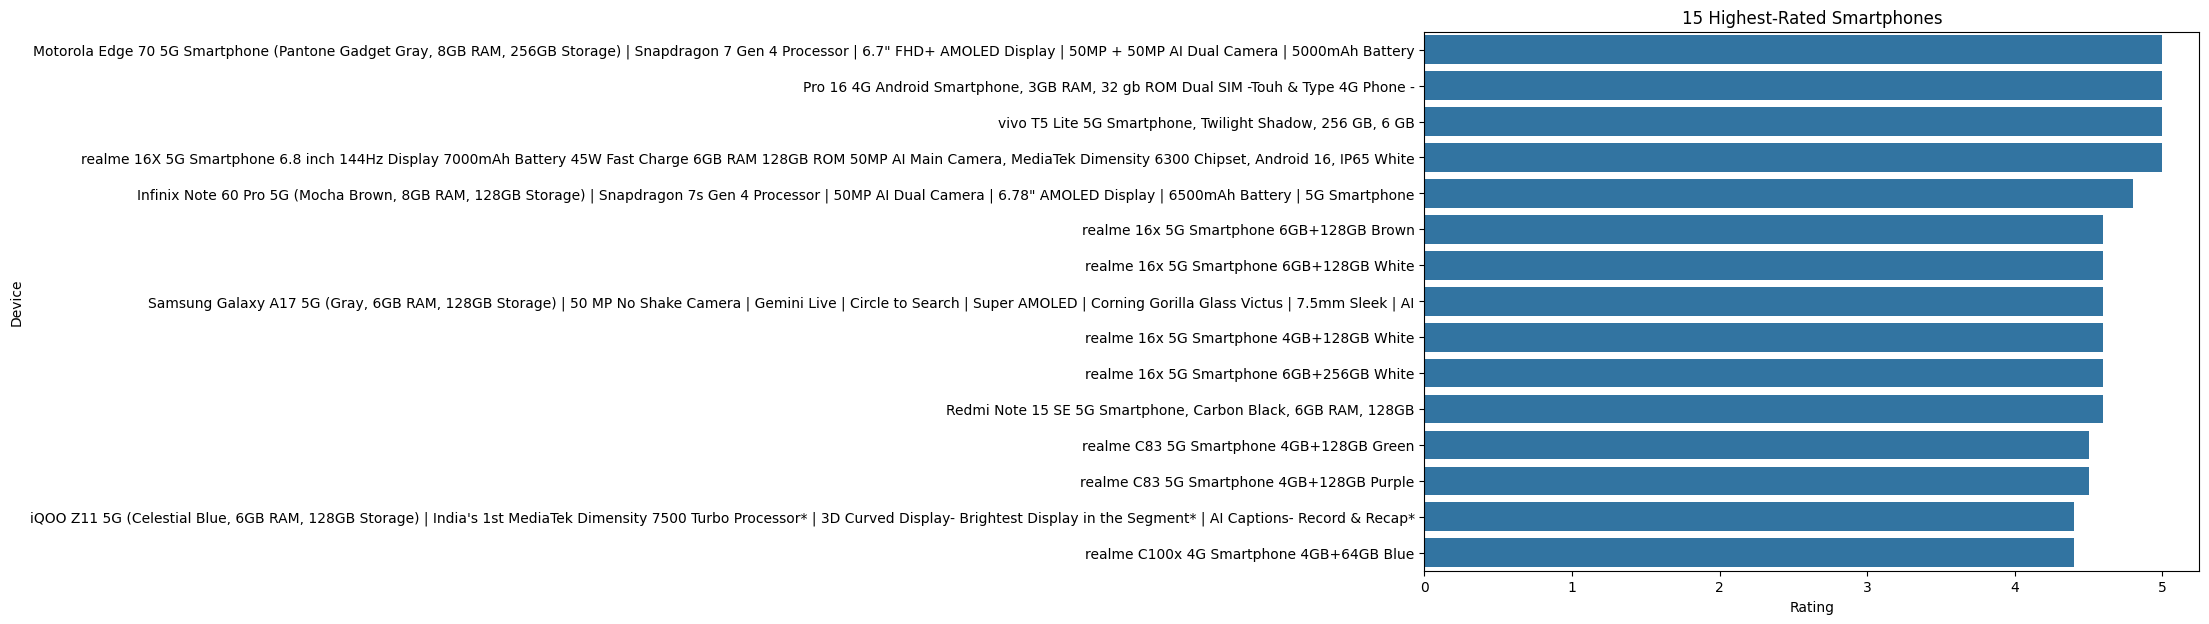

In [181]:
top_rated = (
    df.dropna(subset=['Rating'])
      .sort_values('Rating', ascending=False)
      .head(15)
)

plt.figure(figsize=(10, 7))

sns.barplot(
    data=top_rated,
    x='Rating',
    y='Device'
)

plt.title('15 Highest-Rated Smartphones')
plt.xlabel('Rating')
plt.ylabel('Device')

plt.show()


--------------------------------------------------------------------

# Insights

#### Price distribution

The majority of smartphones are concentrated in the lower-to-mid price range, while relatively few products are priced at the higher end.


#### Rating distribution

Most smartphones have ratings concentrated around the middle-to-high rating range, with fewer products receiving very low ratings.

#### Brand analysis

The dataset contains smartphones from several brands, but the number of products varies considerably between brands.

#### Brand vs average price

Insight: Average smartphone prices differ across brands, indicating that the dataset covers brands positioned at different price segments.

#### Price vs rating

The scatter plot shows that price and rating do not necessarily increase together. Some lower-priced smartphones have high ratings, while some expensive phones have comparatively lower ratings.

#### Data-cleaning insight

The scraped dataset initially contained non-smartphone products such as cases, memory cards, pens, and power banks. These irrelevant products were identified and removed to make the analysis focused on smartphones.